In [2]:
import pandas as pd
from pathlib import Path

# --- 1. Configuración de directorios y fechas ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"

# Replicamos el muestreo de 6 snapshots manteniendo el orden cronológico
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
target_dates = all_dates[::-5][::-1]

# --- 2. Estructura base de la tabla ---
evolution_data = {
    "Nivel de Vulnerabilidad": [
        "🟢 Beta 0.0 (Strict / Commit Pinning)",
        "🟡 Beta 0.1 (Pessimistic SemVer Bounds)",
        "⚪ Beta 0.5 (Complex / Local Fallbacks)",
        "🔴 Beta 1.0 (Branch Tracking / Bare Repo)"
    ]
}

print(f"Calculando evolución del perfil de vulnerabilidad para {len(target_dates)} snapshots...\n")

# --- 3. Iteración y cálculo de ratios ---
for ts in target_dates:
    date_str = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{date_str}.parquet"
    
    if not edge_file.exists():
        print(f" [!] Omitiendo {date_str}: Datos no encontrados.")
        continue
        
    df_edges = pd.read_parquet(edge_file)
    ratio = df_edges['beta'].value_counts(normalize=True) * 100
    
    # Agregamos los porcentajes como una nueva columna etiquetada con la fecha
    evolution_data[date_str] = [
        f"{ratio.get(0.0, 0):.1f}%",
        f"{ratio.get(0.1, 0):.1f}%",
        f"{ratio.get(0.5, 0):.1f}%",
        f"{ratio.get(1.0, 0):.1f}%"
    ]

# --- 4. Generación de la tabla visual ---
df_beta_evolution = pd.DataFrame(evolution_data)

print("Evolución Histórica de Vulnerabilidad en Dependencias (Métrica Beta):")
display(df_beta_evolution)

Calculando evolución del perfil de vulnerabilidad para 6 snapshots...

Evolución Histórica de Vulnerabilidad en Dependencias (Métrica Beta):


,Nivel de Vulnerabilidad,2019-07-02,2020-11-13,2022-03-28,2023-08-10,2024-12-22,2026-05-06
0,🟢 Beta 0.0 (Strict / Commit Pinning),13.4%,9.0%,6.5%,6.3%,6.1%,5.8%
1,🟡 Beta 0.1 (Pessimistic SemVer Bounds),35.0%,36.5%,38.2%,35.5%,35.7%,34.9%
2,⚪ Beta 0.5 (Complex / Local Fallbacks),4.5%,4.7%,4.1%,5.3%,5.2%,5.5%
3,🔴 Beta 1.0 (Branch Tracking / Bare Repo),47.1%,49.8%,51.2%,52.9%,52.9%,53.8%


# Modelo A
Beta constante en 1

Pipeline verificado. Grafos inicializados con 1158 nodos.
Calculando autoridad del ecosistema (PageRank)...
Corriendo Simulaciones del Modelo A...

--- COMPARACIÓN DE MÉTRICAS: BLAST RADIUS vs LCC ---


,Failed (n),Rand Blast %,Rand LCC %,Elite Blast %,Elite LCC %,Perfect Blast %,Perfect LCC %
0,1,0.7,73.3,5.6,72.5,34.9,66.2
1,2,1.1,73.2,10.8,71.4,39.6,65.5
2,3,1.2,73.2,13.3,70.9,39.6,63.3
3,5,1.9,73.0,18.7,69.7,40.9,62.3
4,10,3.3,72.6,27.6,67.0,44.8,59.8
5,15,5.7,71.9,34.4,64.8,44.8,55.5
6,20,6.8,71.6,38.1,63.4,47.2,53.9
7,30,10.0,70.7,42.0,61.3,50.6,50.0
8,40,12.4,69.5,43.4,59.9,52.7,46.4
9,50,16.1,68.3,45.4,57.9,54.0,42.1


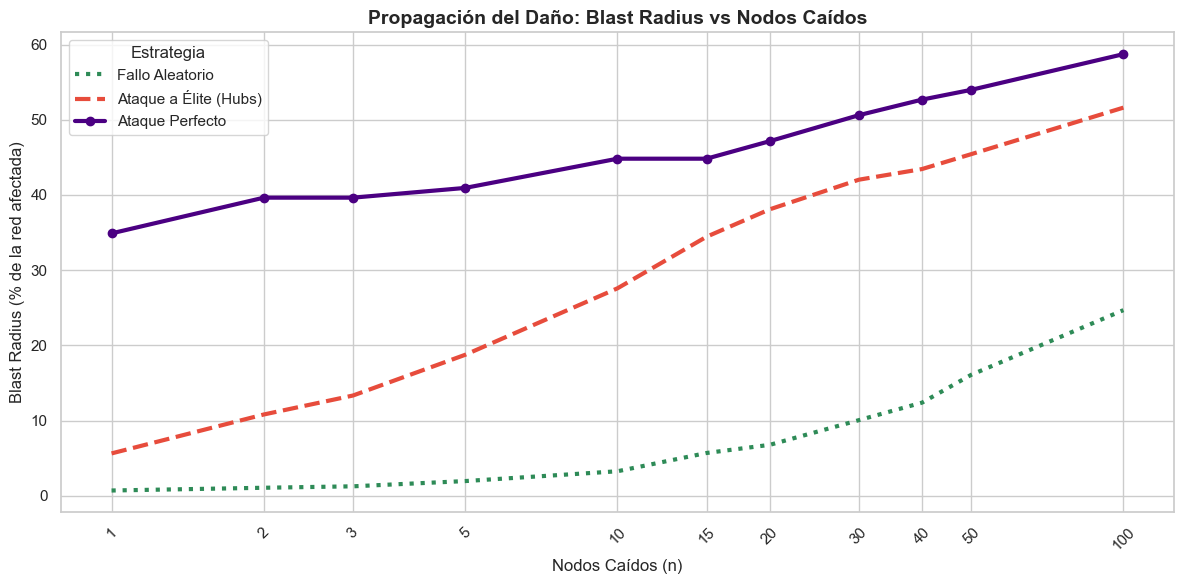

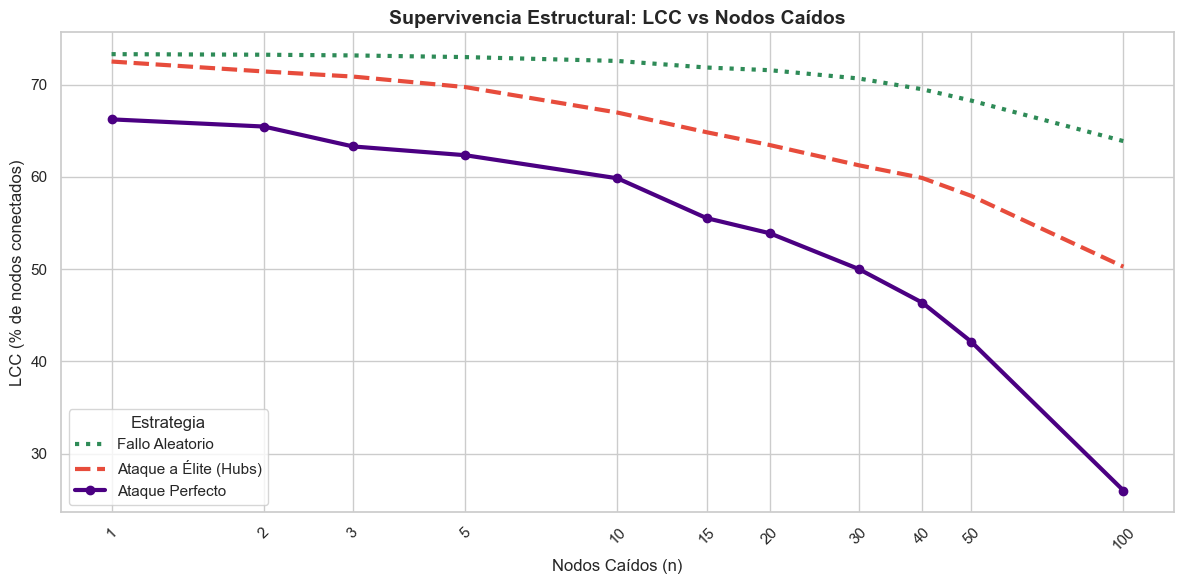

In [3]:
# Modelo de robustez A tomando Beta = 1
import pandas as pd
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Carga de Artefactos Gold ---
anchor_date = "2026-05-06"
nodes_path = Path(f"data/03_gold/gold_nodes_{anchor_date}.parquet")
edges_path = Path(f"data/03_gold/gold_edges_{anchor_date}.parquet")

df_nodes = pd.read_parquet(nodes_path)
df_edges = pd.read_parquet(edges_path)

# --- 2. Inicialización de Grafos (Refactorizado) ---
G_std = nx.from_pandas_edgelist(df_edges, source='source_node', target='target_node', create_using=nx.DiGraph())
G_std.add_nodes_from(df_nodes['node_name'])

# Inversión nativa y eficiente para simular la cascada hacia los dependientes
G_fail = G_std.reverse(copy=True)

total_nodes = G_std.number_of_nodes()
print(f"Pipeline verificado. Grafos inicializados con {total_nodes} nodos.")

# --- 3. Autoridad y Probabilidades ---
print("Calculando autoridad del ecosistema (PageRank)...")
pagerank_scores = nx.pagerank(G_std, alpha=0.85)

# Ordenamiento limpio
sorted_targets = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
top_nodes = [node for node, _ in sorted_targets]

# Arrays para muestreo ponderado
nodes_array = np.array(list(pagerank_scores.keys()))
pr_values = np.array(list(pagerank_scores.values()))
pr_probs = pr_values / pr_values.sum() 

all_nodes = list(G_std.nodes())

# --- 4. Funciones de Medición ---
def calculate_blast_radius(G, failed_nodes):
    total_infected = set(failed_nodes)
    for node in failed_nodes:
        if G.has_node(node):
            total_infected.update(nx.descendants(G, node))
    return len(total_infected)

def calculate_lcc(G, removed_nodes):
    remaining_nodes = set(G.nodes()) - set(removed_nodes)
    G_sub = G.subgraph(remaining_nodes)
    if not G_sub:
        return 0
    return len(max(nx.weakly_connected_components(G_sub), key=len))

# --- 5. Simulación de Modelos (Beta = 1.0) ---
attack_sizes = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 100]
results = []
ITERATIONS = 100

print("Corriendo Simulaciones del Modelo A...\n")

for n in attack_sizes:
    # 1a. Fallo Aleatorio Puro
    random_blast, random_lcc = [], []
    for _ in range(ITERATIONS):
        samp = random.sample(all_nodes, n)
        random_blast.append(calculate_blast_radius(G_fail, samp))
        random_lcc.append(calculate_lcc(G_fail, samp))
        
    # 1b. Ataque Dirigido (Perfecto)
    targ_samp = top_nodes[:n]
    targ_blast = calculate_blast_radius(G_fail, targ_samp)
    targ_lcc = calculate_lcc(G_fail, targ_samp)
    
    # 1c. Ataque Aleatorio a Nodos de Alto Valor (Ponderado)
    hvr_blast, hvr_lcc = [], []
    for _ in range(ITERATIONS):
        samp = np.random.choice(nodes_array, size=n, replace=False, p=pr_probs)
        hvr_blast.append(calculate_blast_radius(G_fail, samp))
        hvr_lcc.append(calculate_lcc(G_fail, samp))
        
    results.append({
        'Failed (n)': n,
        'Rand Blast %': (np.mean(random_blast) / total_nodes) * 100,
        'Rand LCC %': (np.mean(random_lcc) / total_nodes) * 100,
        'Elite Blast %': (np.mean(hvr_blast) / total_nodes) * 100,
        'Elite LCC %': (np.mean(hvr_lcc) / total_nodes) * 100,
        'Perfect Blast %': (targ_blast / total_nodes) * 100,
        'Perfect LCC %': (targ_lcc / total_nodes) * 100
    })

# --- 6. Tabla de Resultados ---
df_model_A = pd.DataFrame(results)
print("--- COMPARACIÓN DE MÉTRICAS: BLAST RADIUS vs LCC ---")
display(df_model_A.round(1))

# --- 7. Visualizaciones Dinámicas ---
sns.set_theme(style="whitegrid")
colors = {'Rand': '#2E8B57', 'Elite': '#E74C3C', 'Perfect': '#4B0082'}

# Gráfico A: Blast Radius
plt.figure(figsize=(12, 6))
plt.plot(df_model_A['Failed (n)'], df_model_A['Rand Blast %'], label='Fallo Aleatorio', color=colors['Rand'], linewidth=3, linestyle=':')
plt.plot(df_model_A['Failed (n)'], df_model_A['Elite Blast %'], label='Ataque a Élite (Hubs)', color=colors['Elite'], linewidth=3, linestyle='--')
plt.plot(df_model_A['Failed (n)'], df_model_A['Perfect Blast %'], label='Ataque Perfecto', color=colors['Perfect'], linewidth=3, marker='o')

plt.title("Propagación del Daño: Blast Radius vs Nodos Caídos", fontsize=14, fontweight='bold')
plt.ylabel("Blast Radius (% de la red afectada)", fontsize=12)
plt.xlabel("Nodos Caídos (n)", fontsize=12)
plt.legend(title="Estrategia", fontsize=11)
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.xticks(attack_sizes, rotation=45) 
plt.tight_layout()
plt.show()

# Gráfico B: Giant Component
plt.figure(figsize=(12, 6))
plt.plot(df_model_A['Failed (n)'], df_model_A['Rand LCC %'], label='Fallo Aleatorio', color=colors['Rand'], linewidth=3, linestyle=':')
plt.plot(df_model_A['Failed (n)'], df_model_A['Elite LCC %'], label='Ataque a Élite (Hubs)', color=colors['Elite'], linewidth=3, linestyle='--')
plt.plot(df_model_A['Failed (n)'], df_model_A['Perfect LCC %'], label='Ataque Perfecto', color=colors['Perfect'], linewidth=3, marker='o')

plt.title("Supervivencia Estructural: LCC vs Nodos Caídos", fontsize=14, fontweight='bold')
plt.ylabel("LCC (% de nodos conectados)", fontsize=12)
plt.xlabel("Nodos Caídos (n)", fontsize=12)
plt.legend(title="Estrategia", fontsize=11)
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.xticks(attack_sizes, rotation=45) 
plt.tight_layout()
plt.show()

# Modelo B
Beta empírico basado en taxonomy.py

Base de datos cargada. Beta empírico promedio del ecosistema: 0.601
Calculando PageRank para identificar Hubs...
Iniciando simulación de propagación de Breaking Changes...



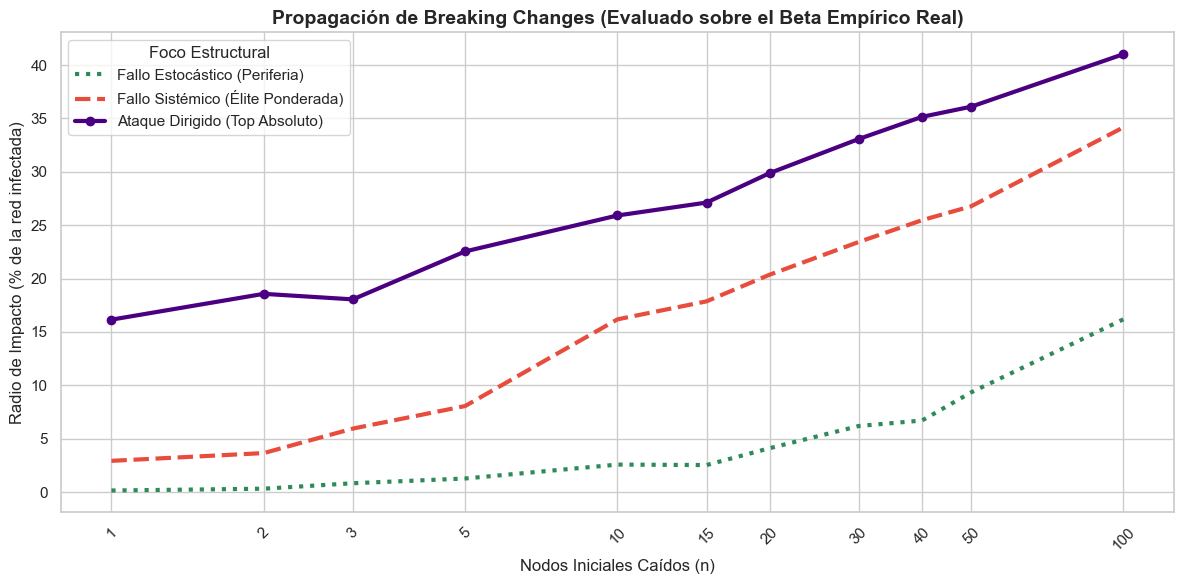

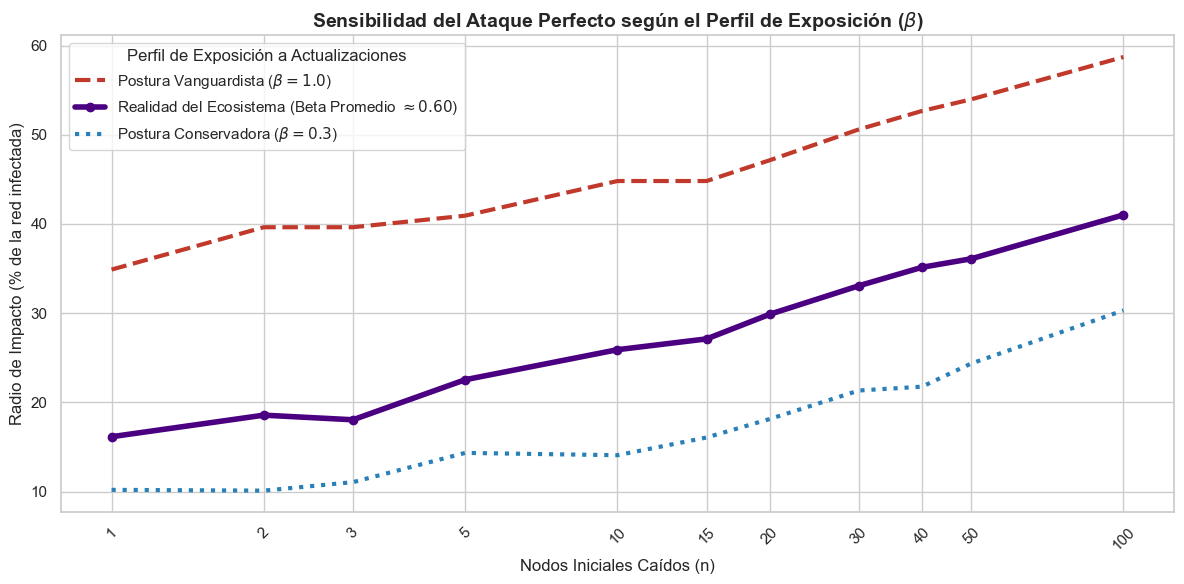


--- RESULTADOS: BREAKING CHANGES (TABLA RESUMEN) ---


,Nodos Caídos,Rand Empírico %,Elite Empírico %,Perfect Empírico %
0,1,0.15,2.92,16.15
1,2,0.31,3.65,18.57
2,3,0.83,5.94,18.05
3,5,1.27,8.06,22.54
4,10,2.57,16.18,25.91
5,15,2.53,17.86,27.12
6,20,4.11,20.36,29.88
7,30,6.19,23.43,33.07
8,40,6.70,25.47,35.15
9,50,9.34,26.77,36.10


In [4]:
# Modelo B, tomando los valores de Beta calculados
import pandas as pd
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import deque

# --- 1. Cargar Datos e Inicializar Grafos ---
anchor_date = "2026-05-06"
nodes_path = Path(f"data/03_gold/gold_nodes_{anchor_date}.parquet")
edges_path = Path(f"data/03_gold/gold_edges_{anchor_date}.parquet")

try:
    df_nodes = pd.read_parquet(nodes_path)
    df_edges = pd.read_parquet(edges_path)
    
    # Extraemos el promedio exacto de la exposición que calculaste en tu taxonomía
    EMPIRICAL_BETA = float(df_edges['beta'].mean())
    print(f"Base de datos cargada. Beta empírico promedio del ecosistema: {EMPIRICAL_BETA:.3f}")
    
except FileNotFoundError:
    print("Archivos no encontrados. Generando un grafo Scale-Free de prueba...")
    EMPIRICAL_BETA = 0.85
    G_mock = nx.barabasi_albert_graph(900, 2, seed=42)
    df_edges = pd.DataFrame(G_mock.edges(), columns=['source_node', 'target_node'])
    df_edges['beta'] = 0.85
    df_nodes = pd.DataFrame({'node_name': list(G_mock.nodes())})

# Inicialización limpia inyectando el atributo 'beta' directamente a las aristas
G_std = nx.from_pandas_edgelist(
    df_edges, 
    source='source_node', 
    target='target_node', 
    edge_attr='beta', 
    create_using=nx.DiGraph()
)
G_std.add_nodes_from(df_nodes['node_name'])

# Inversión nativa para simular el daño fluyendo de target a source
G_fail = G_std.reverse(copy=True)

total_nodes = G_std.number_of_nodes()
all_nodes = list(G_std.nodes())

# --- 2. Identificar la Élite (PageRank) ---
print("Calculando PageRank para identificar Hubs...")
pagerank_scores = nx.pagerank(G_std, alpha=0.85)
sorted_targets = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
top_nodes = [node for node, _ in sorted_targets]

# Arrays para muestreo ponderado (Ataque a Élite)
nodes_array = np.array(list(pagerank_scores.keys()))
pr_values = np.array(list(pagerank_scores.values()))
pr_probs = pr_values / pr_values.sum()

# --- 3. Modelo de Contagio: Breaking Changes (Optimizado) ---
def simulate_breaking_change_cascade(G, initial_nodes, beta=None, use_empirical_edges=False):
    """
    Simula la propagación de un breaking change aguas abajo usando una cola eficiente (deque).
    """
    infected = set(initial_nodes)
    queue = deque(initial_nodes) # deque optimiza la extracción a O(1)
    
    while queue:
        current = queue.popleft()
        for dependent in G.successors(current):
            if dependent not in infected:
                # Obtenemos la probabilidad real de la arista si se solicita, sino usamos la teórica
                prob = G[current][dependent].get('beta', 0.5) if use_empirical_edges else beta
                    
                # El paquete dependiente absorbe el código roto
                if random.random() < prob:
                    infected.add(dependent)
                    queue.append(dependent)
                    
    return len(infected)

# --- 4. Ejecutar Simulación (Barrido por Nodos Afectados) ---
attack_sizes = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 100]
ITERATIONS = 50 

results = []
print("Iniciando simulación de propagación de Breaking Changes...\n")

for n in attack_sizes:
    emp_rand_blast, emp_elite_blast = [], []
    
    for _ in range(ITERATIONS):
        # 1. Fallo Estocástico Heterogéneo
        samp_rand = random.sample(all_nodes, n)
        emp_rand_blast.append(simulate_breaking_change_cascade(G_fail, samp_rand, use_empirical_edges=True))
        
        # 2. Fallo Élite Ponderado Heterogéneo
        samp_elite = np.random.choice(nodes_array, size=n, replace=False, p=pr_probs)
        emp_elite_blast.append(simulate_breaking_change_cascade(G_fail, samp_elite, use_empirical_edges=True))
    
    # 3. Ataque Perfecto (Top Absoluto) en 3 escenarios de Beta distintos
    samp_perf = top_nodes[:n]
    
    # Escenario A: Realidad Empírica (Usa los valores reales de los Shards)
    emp_perf_blast = simulate_breaking_change_cascade(G_fail, samp_perf, use_empirical_edges=True)
    # Escenario B: Todos Vanguardistas (Peor caso teórico)
    perf_beta_10 = simulate_breaking_change_cascade(G_fail, samp_perf, beta=1.0, use_empirical_edges=False)
    # Escenario C: Comunidad Conservadora (Mejor caso teórico, ej. beta=0.3)
    perf_beta_03 = simulate_breaking_change_cascade(G_fail, samp_perf, beta=0.3, use_empirical_edges=False)
    
    results.append({
        'Nodos Caídos': n,
        'Rand Empírico %': (np.mean(emp_rand_blast) / total_nodes) * 100,
        'Elite Empírico %': (np.mean(emp_elite_blast) / total_nodes) * 100,
        'Perfect Empírico %': (emp_perf_blast / total_nodes) * 100,
        'Perfect (Beta 1.0) %': (perf_beta_10 / total_nodes) * 100,
        'Perfect (Beta 0.3) %': (perf_beta_03 / total_nodes) * 100,
    })

df_breaking = pd.DataFrame(results)

# --- 5. Visualización Dinámica ---
sns.set_theme(style="whitegrid")

# GRÁFICO 1: Estrategias de Ataque en la Realidad Empírica
colors_strategy = {'Rand': '#2E8B57', 'Elite': '#E74C3C', 'Perfect': '#4B0082'}

plt.figure(figsize=(12, 6))
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Rand Empírico %'], 
         label='Fallo Estocástico (Periferia)', color=colors_strategy['Rand'], linewidth=3, linestyle=':')
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Elite Empírico %'], 
         label='Fallo Sistémico (Élite Ponderada)', color=colors_strategy['Elite'], linewidth=3, linestyle='--')
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Perfect Empírico %'], 
         label='Ataque Dirigido (Top Absoluto)', color=colors_strategy['Perfect'], linewidth=3, marker='o')

plt.title("Propagación de Breaking Changes (Evaluado sobre el Beta Empírico Real)", fontsize=14, fontweight='bold')
plt.ylabel("Radio de Impacto (% de la red infectada)", fontsize=12)
plt.xlabel("Nodos Iniciales Caídos (n)", fontsize=12)
plt.legend(title="Foco Estructural", fontsize=11, loc='upper left')

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.xticks(attack_sizes, rotation=45) 
plt.tight_layout()
plt.show()

# GRÁFICO 2: El impacto de Beta ante el Peor Escenario (Ataque Perfecto)
colors_beta = {'Beta 1.0': '#C0392B', 'Empirico': '#4B0082', 'Beta 0.3': '#2980B9'}

plt.figure(figsize=(12, 6))
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Perfect (Beta 1.0) %'], 
         label=r'Postura Vanguardista ($\beta=1.0$)', color=colors_beta['Beta 1.0'], linewidth=3, linestyle='--')
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Perfect Empírico %'], 
         label=f'Realidad del Ecosistema (Beta Promedio $\\approx {EMPIRICAL_BETA:.2f}$)', color=colors_beta['Empirico'], linewidth=4, marker='o')
plt.plot(df_breaking['Nodos Caídos'], df_breaking['Perfect (Beta 0.3) %'], 
         label=r'Postura Conservadora ($\beta=0.3$)', color=colors_beta['Beta 0.3'], linewidth=3, linestyle=':')

plt.title(r"Sensibilidad del Ataque Perfecto según el Perfil de Exposición ($\beta$)", fontsize=14, fontweight='bold')
plt.ylabel("Radio de Impacto (% de la red infectada)", fontsize=12)
plt.xlabel("Nodos Iniciales Caídos (n)", fontsize=12)
plt.legend(title="Perfil de Exposición a Actualizaciones", fontsize=11, loc='upper left')

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.xticks(attack_sizes, rotation=45) 
plt.tight_layout()
plt.show()

print("\n--- RESULTADOS: BREAKING CHANGES (TABLA RESUMEN) ---")
display(df_breaking[['Nodos Caídos', 'Rand Empírico %', 'Elite Empírico %', 'Perfect Empírico %']].round(2))

# Métricas de repositorios
Basadas en CHAOSS

In [ ]:
import importlib
import src.repo_metrics
importlib.reload(src.repo_metrics)
from src.repo_metrics import get_chaoss_metrics
import getpass
import pandas as pd


# --- 1. Credenciales y Configuración ---
GITHUB_TOKEN = getpass.getpass("Ingresa tu GitHub token (input hidden): ")

REPOS_TO_ANALYZE = [
    "crystal-ameba/ameba",
    "kemalcr/kemal",
    "ysbaddaden/minitest.cr",
    "crystal-lang/crystal-db",
    "manastech/webmock.cr",
    "luislavena/radix",
    "crystal-loot/exception_page"
]

# --- 2. Ejecución de la API ---
print(f"Iniciando extracción de métricas CHAOSS para {len(REPOS_TO_ANALYZE)} repositorios...")
metrics_data = get_chaoss_metrics(repos=REPOS_TO_ANALYZE, token=GITHUB_TOKEN)

# --- 3. Renderizado de Resultados ---
df_chaoss = pd.DataFrame(metrics_data)

# Reordenamos y limpiamos las columnas para una mejor presentación visual
if 'error' not in df_chaoss.columns:
    df_chaoss = df_chaoss[[
        'repo', 'bus_factor', 'top_contributor_share_pct', 
        'active_contributors_90d', 'total_contributors_1y', 
        'new_contributors_30d', 'contributor_growth_delta'
    ]]

print("\n🏁 Extracción finalizada. Resumen de Métricas CHAOSS:")
display(df_chaoss)

ImportError: cannot import name 'get_chaoss_metrics' from 'src.repo_metrics' (/Users/manumoreira/Repos/tt1/crystal-dn/src/repo_metrics.py)